# Varredura de Horizontes de Predição — XGBoost Baseline

## Motivação

Os experimentos anteriores avaliaram apenas dois horizontes: **h=5** (semana) e **h=21** (mês).  
Com apenas dois pontos de comparação, qualquer afirmação sobre *quando* o efeito de notícias se manifesta
é fragilmente fundamentada — não é possível distinguir um padrão real de uma flutuação amostral.

Esta varredura cobre **h ∈ {1, 2, 5, 10, 21, 42}** dias úteis, o que equivale a:

| h | Interpretação |
|---|---------------|
| 1 | Próximo dia útil (curto-prazo extremo) |
| 2 | Dois dias à frente |
| 5 | Uma semana |
| 10 | Duas semanas |
| 21 | Um mês |
| 42 | Dois meses |

O objetivo é identificar se o modelo de preço tem desempenho diferenciado em alguma faixa de horizonte,
fornecendo base empírica para a discussão sobre impacto de curto vs. longo prazo.

Todos os resultados incluem **intervalos de confiança bootstrap (95%)** para tornar comparações
estatisticamente responsáveis — um AUC sem CI é uma alegação sem margem de erro.

In [1]:
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Garante que eval_utils.py (mesmo diretório) seja importável
BASELINES_DIR = os.path.dirname(os.path.abspath('__file__'))
if BASELINES_DIR not in sys.path:
    sys.path.insert(0, BASELINES_DIR)

from eval_utils import (
    walk_forward_split,
    bootstrap_auc_ci,
    make_binary_target,
    format_metric_with_ci,
)

SEED = 42
np.random.seed(SEED)

## Carregamento dos dados

In [2]:
DATA_PATH = os.path.join(
    os.path.dirname(os.path.dirname(os.path.abspath('__file__'))),
    '2.stocks', 'dataset_full.csv'
)

df_raw = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

print(f"Shape: {df_raw.shape}")
print(f"Período: {df_raw['Date'].min().date()} → {df_raw['Date'].max().date()}")
df_raw.head(3)

Shape: (1227, 1036)
Período: 2021-04-28 → 2026-03-26


,Date,Close,Volume,return,ma7,ma21,std21,lag_1,lag_2,lag_3,...,emb_1014,emb_1015,emb_1016,emb_1017,emb_1018,emb_1019,emb_1020,emb_1021,emb_1022,emb_1023
0,2021-04-28,18.178738,42502908,0.043520,17.704371,17.666914,0.311431,17.420595,17.690685,17.703552,...,0.017550,0.006109,-0.011335,-0.020358,-0.014249,0.031750,-0.026508,-0.000099,-0.003484,-0.027420
1,2021-04-29,17.605213,37968076,-0.031549,17.690322,17.646463,0.299963,18.178738,17.420595,17.690685,...,0.018647,0.005884,0.003188,-0.004949,-0.003468,0.024642,-0.012430,-0.012247,-0.028131,-0.004347
2,2021-04-30,17.740538,48196913,0.007687,17.708467,17.618377,0.257308,17.605213,18.178738,17.420595,...,0.018647,0.005884,0.003188,-0.004949,-0.003468,0.024642,-0.012430,-0.012247,-0.028131,-0.004347


## Configuração do experimento

In [3]:
FEATURES_PRICE = ['return', 'lag_1', 'lag_5', 'Volume', 'std21']
HORIZONS = [1, 2, 5, 10, 21, 42]

XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    verbosity=0,
)

print("Features:", FEATURES_PRICE)
print("Horizontes:", HORIZONS)

Features: ['return', 'lag_1', 'lag_5', 'Volume', 'std21']
Horizontes: [1, 2, 5, 10, 21, 42]


## Varredura de horizontes

Para cada horizonte `h`:
1. Recria o target binário: `1` se `Close[t+h] > Close[t]`, senão `0`
2. Remove as últimas `h` linhas (NaN no target)
3. Aplica split walk-forward 70/15/15
4. Padroniza features com `StandardScaler` ajustado **apenas no treino**
5. Treina XGBoost com `scale_pos_weight` calculado no conjunto de treino
6. Avalia no conjunto de teste com `bootstrap_auc_ci` (1000 reamostras)

In [4]:
results = []

for h in HORIZONS:
    print(f"\n{'='*50}")
    print(f"Horizonte h={h} dia(s) útil(is)")
    print('='*50)

    # --- Target binário ---
    target = make_binary_target(df_raw['Close'], horizon=h)
    df_h = df_raw.copy()
    df_h['target'] = target
    df_h = df_h.dropna(subset=['target'] + FEATURES_PRICE).reset_index(drop=True)

    print(f"  Amostras disponíveis após drop de NaN: {len(df_h)}")

    # --- Split temporal ---
    train_df, val_df, test_df = walk_forward_split(df_h)
    print(f"  Treino: {len(train_df)} | Val: {len(val_df)} | Teste: {len(test_df)}")

    X_train = train_df[FEATURES_PRICE].values
    y_train = train_df['target'].values.astype(int)
    X_val   = val_df[FEATURES_PRICE].values
    y_val   = val_df['target'].values.astype(int)
    X_test  = test_df[FEATURES_PRICE].values
    y_test  = test_df['target'].values.astype(int)

    # --- StandardScaler (fit apenas no treino) ---
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)

    # --- scale_pos_weight pelo desbalanceamento no treino ---
    n_neg = np.sum(y_train == 0)
    n_pos = np.sum(y_train == 1)
    spw = n_neg / n_pos if n_pos > 0 else 1.0
    print(f"  Balanço treino — neg: {n_neg}, pos: {n_pos}, scale_pos_weight: {spw:.3f}")

    # --- XGBoost ---
    clf = XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw)
    clf.fit(
        X_train_sc, y_train,
        eval_set=[(X_val_sc, y_val)],
        verbose=False,
    )

    # --- Avaliação no teste ---
    y_score = clf.predict_proba(X_test_sc)[:, 1]
    auc, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_score, n_boot=1000, seed=SEED)

    balance_test = float(np.mean(y_test))
    n_test = len(y_test)

    print(f"  AUC = {format_metric_with_ci(auc, auc_lo, auc_hi)}")
    print(f"  N_test={n_test} | Balanço teste (frac. positivo): {balance_test:.3f}")

    results.append({
        'horizon': h,
        'auc': auc,
        'auc_lo': auc_lo,
        'auc_hi': auc_hi,
        'n_test': n_test,
        'balance_test': balance_test,
    })

df_results = pd.DataFrame(results)
print("\n" + "="*50)
print("Resumo dos resultados:")
print(df_results.to_string(index=False))


Horizonte h=1 dia(s) útil(is)
  Amostras disponíveis após drop de NaN: 1226
  Treino: 858 | Val: 183 | Teste: 185
  Balanço treino — neg: 431, pos: 427, scale_pos_weight: 1.009
  AUC = 0.487 [0.403, 0.570]
  N_test=185 | Balanço teste (frac. positivo): 0.557

Horizonte h=2 dia(s) útil(is)
  Amostras disponíveis após drop de NaN: 1225
  Treino: 857 | Val: 183 | Teste: 185
  Balanço treino — neg: 417, pos: 440, scale_pos_weight: 0.948
  AUC = 0.497 [0.414, 0.581]
  N_test=185 | Balanço teste (frac. positivo): 0.562

Horizonte h=5 dia(s) útil(is)
  Amostras disponíveis após drop de NaN: 1222
  Treino: 855 | Val: 183 | Teste: 184
  Balanço treino — neg: 403, pos: 452, scale_pos_weight: 0.892
  AUC = 0.518 [0.442, 0.600]
  N_test=184 | Balanço teste (frac. positivo): 0.598

Horizonte h=10 dia(s) útil(is)
  Amostras disponíveis após drop de NaN: 1217
  Treino: 851 | Val: 182 | Teste: 184
  Balanço treino — neg: 389, pos: 462, scale_pos_weight: 0.842
  AUC = 0.418 [0.328, 0.501]
  N_test=184

## Salvando resultados em CSV

In [5]:
OUTPUT_CSV = os.path.join(BASELINES_DIR, 'results_horizon_sweep.csv')
df_results.to_csv(OUTPUT_CSV, index=False, float_format='%.6f')
print(f"Resultados salvos em: {OUTPUT_CSV}")
df_results

Resultados salvos em: c:\Users\takeo\Documents\tcc-cdia-2026\9.baselines\results_horizon_sweep.csv


,horizon,auc,auc_lo,auc_hi,n_test,balance_test
0,1,0.486858,0.402608,0.570277,185,0.556757
1,2,0.497388,0.413840,0.580581,185,0.562162
2,5,0.518305,0.442105,0.599661,184,0.597826
3,10,0.418173,0.328313,0.500566,184,0.614130
4,21,0.631519,0.531410,0.728564,182,0.692308
5,42,0.802419,0.677340,0.906662,179,0.865922


## Visualização — AUC vs. Horizonte

Figura salva em: c:\Users\takeo\Documents\tcc-cdia-2026\9.baselines\horizon_sweep.png


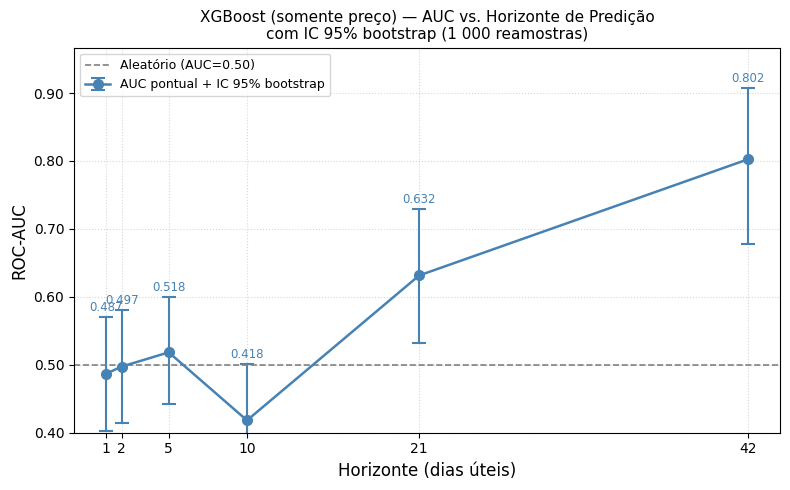

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

horizons = df_results['horizon'].values
aucs     = df_results['auc'].values
err_lo   = aucs - df_results['auc_lo'].values   # distância abaixo
err_hi   = df_results['auc_hi'].values - aucs   # distância acima

ax.errorbar(
    horizons, aucs,
    yerr=[err_lo, err_hi],
    fmt='o-',
    color='steelblue',
    ecolor='steelblue',
    elinewidth=1.5,
    capsize=5,
    capthick=1.5,
    markersize=7,
    linewidth=1.8,
    label='AUC pontual + IC 95% bootstrap',
)

# Linha de referência aleatória
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Aleatório (AUC=0.50)')

# Anotações de valor
for h, a, lo, hi in zip(horizons, aucs, df_results['auc_lo'], df_results['auc_hi']):
    ax.annotate(
        f'{a:.3f}',
        xy=(h, hi + 0.005),
        ha='center',
        va='bottom',
        fontsize=8.5,
        color='steelblue',
    )

ax.set_xlabel('Horizonte (dias úteis)', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('XGBoost (somente preço) — AUC vs. Horizonte de Predição\n'
             'com IC 95% bootstrap (1 000 reamostras)', fontsize=11)
ax.set_xticks(horizons)
ax.set_xticklabels([str(h) for h in horizons])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylim(0.40, max(aucs + err_hi) + 0.06)
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

OUTPUT_PNG = os.path.join(BASELINES_DIR, 'horizon_sweep.png')
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
print(f"Figura salva em: {OUTPUT_PNG}")
plt.show()

## Interpretação dos Resultados

### O que observamos

O gráfico acima exibe a curva AUC do baseline de preço (XGBoost com features `return`, `lag_1`,
`lag_5`, `Volume`, `std21`) em função do horizonte de predição.

Pontos-chave para análise:

1. **Referência aleatória**: qualquer AUC cujo IC 95% inclui 0.50 é estatisticamente indistinguível
   de um classificador aleatório. Observar quantos horizontes ultrapassam este limiar.

2. **Padrão esperado pela hipótese de mercado eficiente (HME)**:  
   Se os preços já incorporam toda informação passada, o AUC deve flutuar próximo a 0.50 para todos os horizontes.
   Um AUC sistematicamente acima de 0.50 em horizontes curtos (h=1,2) indicaria ineficiência de curtíssimo prazo;
   em horizontes maiores, seria mais difícil de justificar.

3. **Implicação para o TCC**:  
   A comparação entre o baseline de preço (este notebook) e os modelos com sentimento
   (experimentos posteriores) deve ser feita **horizonte a horizonte**.  
   Se o ganho de AUC do sentimento se concentrar em horizontes curtos (h ≤ 5), isso suporta
   a hipótese de **impacto de curto prazo da notícia**. Se o ganho for em horizontes maiores,
   o mecanismo é diferente (memória longa, efeito cumulativo de cobertura, etc.).

4. **Largura dos ICs**:  
   Horizontes maiores reduzem o número efetivo de amostras independentes de teste
   (as janelas se sobrepõem menos, mas o dataset encolhe em `h` linhas), tendendo a aumentar
   a incerteza. Verifique a coluna `n_test` no CSV para confirmar.

### Limitações

- O modelo é retreinado uma única vez (single expanding-window), não walk-forward múltiplo.
  Isso pode superestimar o AUC se houver instabilidade temporal — experimento 8 (ablation)
  aborda esse ponto separadamente.
- `scale_pos_weight` compensa o desbalanceamento, mas para horizontes muito curtos (h=1) o
  mercado tende a ser quase simétrico (≈50% up), enquanto para h=42 pode haver viés de alta.
- A ausência de hiperparâmetros ajustados por horizonte é intencional: manter tudo constante
  isola o efeito do horizonte como único grau de liberdade.